# Bab 3 — Statistical Experiments and Significance Testing

**Tujuan pembelajaran.** merancang pertanyaan A/B; menyatakan hipotesis dan arah uji; menjalankan permutasi, t-test, ANOVA, chi-square, serta exact test; membedakan signifikansi dan ukuran efek; menjelaskan multiplicity, bandit, power, dan ukuran sampel.

**Ringkasan bab.** Perbedaan teramati dapat berasal dari treatment atau variasi acak. Desain eksperimen menyediakan dasar perbandingan; uji statistik menilai ketidakcocokan data dengan model nol. P-value harus dibaca bersama ukuran efek, ketidakpastian, biaya keputusan, dan asumsi. Banyak percobaan atau pemilihan hasil setelah melihat data meningkatkan false positives.

Notebook belajar dan reproduksi edisi kedua (Bruce, Bruce, Gedeck, 2020). Penjelasan ditulis ulang dengan bantuan AI; kode diadaptasi dari repository resmi berlisensi GPL-3.0. Angka dan grafik di bawah berasal dari eksekusi sel. Bagian tambahan diberi label. Gunakan **Restart Kernel → Run All**. Nomor halaman merujuk halaman cetak; nomor PDF = cetak + 18.

**Cara belajar:** baca tujuan setiap bagian, jalankan sel, lalu jelaskan output dengan kalimat sendiri sebelum melihat interpretasinya. Catat mengapa metode tersebut cocok, bukan hanya nama fungsinya.

## Setup dan dataset


| File / sumber | Unit dan kolom | Perlakuan |
|---|---|---|
| `web_page_data.csv` | 36 sesi A/B, `Page`, `Time` | `Time × 100` menjadi detik sesuai kode resmi (bukan ×60) |
| Tabel 3-1/3-2 buku (cetak 90/104) | Konversi 200/23.739 vs 182/22.588 | Tabel hitungan ditranskripsikan, bukan data dummy |
| `four_sessions.csv` | 20 sesi, 4 halaman ×5, `Time` dalam detik | ANOVA; tiap kolom buku berisi pengunjung berbeda, bukan pasangan |
| `click_rates.csv` | Klik/no-click pada 3 headline ×1.000 exposure | `Rate` sebenarnya **hitungan**, bukan probabilitas |
| `imanishi_data.csv` | 315 digit, frekuensi 0–9 | Contoh goodness of fit; nama kolom mengandung spasi |

Randomisasi dan independensi merupakan asumsi desain contoh buku, bukan sesuatu yang bisa dibuktikan hanya dari CSV. Tidak ada eksperimen baru pada pengguna nyata.


Sumber file: [repository pendamping edisi kedua](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa/data). Commit sumber dan checksum dicatat di `data/manifest.json`. Data bukan hasil simulasi kecuali dinyatakan secara eksplisit.

In [1]:
%matplotlib inline
import os
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from importlib.metadata import version

ROOT = Path.cwd()
if not (ROOT / "data/manifest.json").exists():
    raise FileNotFoundError("Buka folder proyek sebagai workspace dan jalankan notebook dari root proyek.")
DATA = ROOT / "data"
SEED = 1
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)
print("Python:", sys.version.split()[0], "| Interpreter:", sys.executable)
print("Data:", DATA.relative_to(ROOT))
import random
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.special import gammaln, logsumexp
session = pd.read_csv(DATA / 'web_page_data.csv')
session['Time'] = 100 * session['Time']
four = pd.read_csv(DATA / 'four_sessions.csv')
click_rate = pd.read_csv(DATA / 'click_rates.csv')
digits = pd.read_csv(DATA / 'imanishi_data.csv')
digits.columns=digits.columns.str.strip()
for name,df in [('session',session),('four',four),('click_rate',click_rate),('digits',digits)]:
    print(name,df.shape,'missing:',int(df.isna().sum().sum()))
display(session.groupby('Page').Time.agg(['count','mean','std']))
display(click_rate)

Python: 3.13.5 | Interpreter: /Users/happhify/Telkom/Machine Learning/Practical-Statistics-for-Data-Scientists/.venv/bin/python
Data: data


session (36, 2) missing: 0
four (20, 2) missing: 0
click_rate (6, 3) missing: 0
digits (10, 2) missing: 0


,count,mean,std
Page,,,
Page A,21,126.333333,88.463175
Page B,15,162.000000,101.136400


,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


<a id="c3-01"></a>
## A/B Testing

*Acuan: cetak 88; PDF 106. Jenis: Teori.*

A/B test membandingkan dua treatment pada kelompok subjek berbeda. Subjek bisa pengunjung situs, perangkat, atau unit produk. **Random assignment** menentukan treatment untuk subjek; **random sampling** menentukan subjek dari populasi. Keduanya bukan proses yang sama. Tetapkan unit randomisasi, metrik utama, ukuran efek minimal, dan aturan penghentian sebelum eksperimen.

Contoh buku membandingkan halaman web melalui lama sesi. Lama sesi adalah proxy ketertarikan, bukan penjualan itu sendiri. Pengunjung yang melihat kedua versi berulang dapat menyebabkan dependensi; desain harus mencegah kontaminasi atau memperhitungkannya.

<a id="c3-02"></a>
## Why Have a Control Group?

*Acuan: cetak 90; PDF 108. Jenis: Teori.*

Kelompok kontrol mengalami kondisi serupa selain treatment yang diuji. Membandingkan hasil baru dengan bulan lalu saja dapat mencampurkan efek treatment dengan musim, perangkat, atau komposisi pengguna. Randomisasi membantu menyeimbangkan faktor tersebut **dalam harapan**, bukan menjamin setiap sampel seimbang sempurna.

Blinding menyembunyikan treatment dari subjek; double-blinding juga menyembunyikannya dari pelaksana/pengukur bila memungkinkan. Untuk eksperimen web tertentu blinding tidak penuh. Contoh etika eksperimen newsfeed yang dibahas buku mengingatkan bahwa dampak intervensi dan pemahaman peserta tetap perlu dipertimbangkan; bagian ini bukan instruksi menjalankan eksperimen pada manusia.

<a id="c3-03"></a>
## Why Just A/B? Why Not C, D,…?

*Acuan: cetak 91; PDF 109. Jenis: Teori.*

Lebih dari dua treatment dapat diuji, tetapi banyak perbandingan pasangan meningkatkan peluang salah positif. ANOVA dan chi-square menyediakan uji keseluruhan, sedangkan multi-arm bandit mengalokasikan trafik secara adaptif untuk meningkatkan reward. Desain fixed-horizon yang menilai hipotesis berbeda tujuan dari kebijakan adaptif yang mengoptimalkan hasil selama percobaan.

Durasi “seminggu” atau jumlah “1.000 pengunjung” bukan aturan umum yang memadai; ukuran efek, laju kejadian, alpha, dan power menentukan kebutuhan data.

<a id="c3-04"></a>
## Hypothesis Tests

*Acuan: cetak 93; PDF 111. Jenis: Teori.*

Hypothesis test membandingkan statistik observasi dengan distribusi acuan di bawah hipotesis nol. Alur yang sehat: pertanyaan → desain → pengumpulan → analisis → keputusan. Menetapkan statistik setelah mengamati hasil membuka peluang bias. Deretan hasil yang tampak berpola dapat tetap terjadi secara acak; intuisi manusia sering meremehkan run panjang atau kejadian ekstrem.

<a id="c3-05"></a>
## The Null Hypothesis

*Acuan: cetak 94; PDF 112. Jenis: Teori.*

Hipotesis nol $H_0$ menetapkan baseline, misalnya distribusi lama sesi tidak berbeda antarhalaman. Dalam permutasi, label A/B dianggap **exchangeable** di bawah $H_0$; penggabungan nilai lalu pengacakan label membangun null model.

Kesamaan mean saja tidak selalu cukup untuk pertukaran label mentah jika varians atau desain kelompok berbeda. Uji permutasi sederhana di sini mengikuti asumsi desain buku. P-value dihitung **dengan mengasumsikan $H_0$**, bukan menghitung probabilitas $H_0$ benar.

<a id="c3-06"></a>
## Alternative Hypothesis

*Acuan: cetak 95; PDF 113. Jenis: Teori.*

Untuk pertanyaan apakah B meningkatkan waktu sesi, gunakan $H_1:\mu_B>\mu_A$, dengan $H_0:\mu_B\le\mu_A$; null distribution lazimnya dibangun pada batas kesamaan. Untuk sekadar perbedaan, $H_1:\mu_B\ne\mu_A$. Alternatif harus sesuai metrik bisnis: durasi lebih lama belum tentu lebih baik jika pengguna kesulitan menemukan informasi.

<a id="c3-07"></a>
## One-Way Versus Two-Way Hypothesis Tests

*Acuan: cetak 95; PDF 113. Jenis: Teori.*

Uji satu sisi menghitung hasil ekstrem pada arah yang ditentukan sebelumnya. Uji dua sisi mempertimbangkan penyimpangan kedua arah, misalnya $|\bar X_B-\bar X_A|$. Jangan memilih satu sisi setelah melihat arah hasil.

Notebook memakai arah **B−A** untuk waktu sesi dan **A−B** untuk konversi harga, mengikuti pertanyaan masing-masing. API `alternative` dipakai untuk Welch t-test supaya arah eksplisit. Membagi p-value dua sisi dengan dua hanya valid pada kasus tertentu dan harus memperhatikan arah statistik.

<a id="c3-08"></a>
## Resampling

*Acuan: cetak 96; PDF 114. Jenis: Teori.*

Bootstrap menilai variasi estimator dengan resampling dari sampel. Permutation membentuk benchmark model nol dengan mengalokasikan ulang data ke kelompok. Metode berbasis komputer mengurangi kebutuhan rumus distribusi khusus, tetapi tidak menghilangkan asumsi desain, independensi, atau exchangeability.

<a id="c3-09"></a>
## Permutation Test

*Acuan: cetak 97; PDF 115. Jenis: Adaptasi Python buku dengan definisi arah eksplisit.*

Gabungkan semua nilai, acak tanpa replacement, pecah ke ukuran kelompok semula, hitung selisih mean, lalu ulangi $B$ kali. Untuk uji satu sisi B>A, nilai ekstrem berarti $\Delta^*\ge\Delta_{obs}$.

Buku memakai proporsi `>`; notebook juga menampilkan versi dengan ties dan koreksi Monte Carlo $(b+1)/(B+1)$, dengan $b$ jumlah statistik acak setidaknya se-ekstrem observasi. Koreksi mencegah p-value nol hanya karena simulasi terbatas. Implementasi memakai posisi NumPy agar tidak bergantung pada label indeks pandas.

In [2]:
def perm_diff_b_minus_a(values,n_a,n_b,rng):
    values=np.asarray(values)
    assert len(values)==n_a+n_b
    shuffled=rng.permutation(values)
    return shuffled[n_a:].mean()-shuffled[:n_a].mean()

def monte_carlo_p(null_values,observed):
    # isclose menangani ties yang berbeda hanya karena floating point.
    extreme=(null_values>observed) | np.isclose(null_values,observed,rtol=1e-12,atol=1e-12)
    return (extreme.sum()+1)/(len(null_values)+1)

<a id="c3-10"></a>
## Example: Web Stickiness

*Acuan: cetak 98; PDF 116. Jenis: Reproduksi Python buku.*

Reproduksi membandingkan 21 sesi A dan 15 sesi B. Nol durasi akibat pengukuran sesi terakhir dibahas buku sebagai masalah preprocessing; CSV yang tersedia sudah merupakan data contoh siap analisis. Kita tidak menghapus sesi tambahan tanpa informasi sumber.

Hipotesis alternatif yang dipakai: B memiliki mean durasi lebih tinggi. Statistik selisih mean bersatuan detik. Boxplot menunjukkan variasi individual, sedangkan histogram permutasi menunjukkan variasi statistik di bawah null model.

Mean A=126.3333, mean B=162.0000; B−A=35.66667 detik
Proporsi strict > (gaya buku): 0.1270
p Monte Carlo (ties + koreksi): 0.1279
SE Monte Carlo aproksimasi: 0.0106


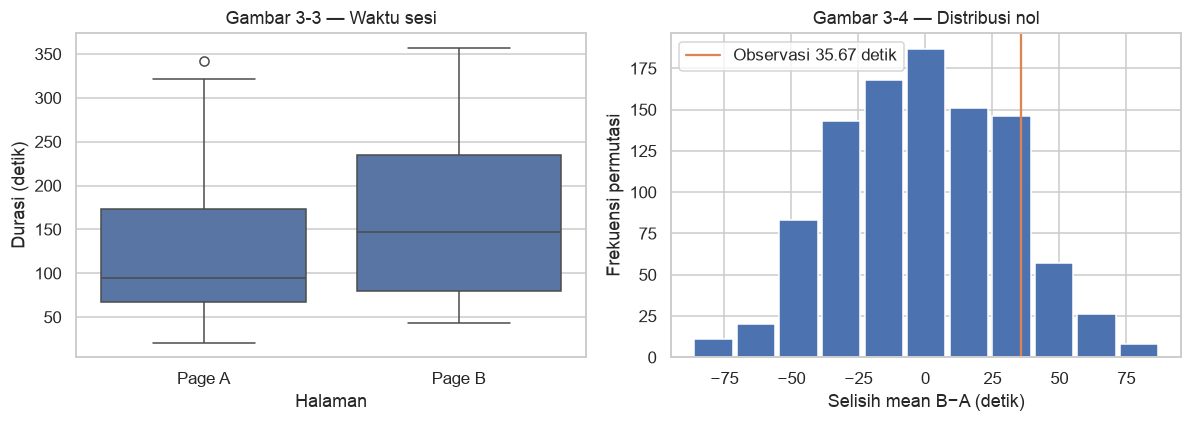

In [3]:
a=session.loc[session.Page=='Page A','Time']
b=session.loc[session.Page=='Page B','Time']
observed=b.mean()-a.mean()
rng_perm=np.random.default_rng(SEED)
perm_times=np.array([perm_diff_b_minus_a(session.Time,len(a),len(b),rng_perm) for _ in range(1000)])
p_times=monte_carlo_p(perm_times,observed)
print(f'Mean A={a.mean():.4f}, mean B={b.mean():.4f}; B−A={observed:.5f} detik')
print(f'Proporsi strict > (gaya buku): {np.mean(perm_times>observed):.4f}')
print(f'p Monte Carlo (ties + koreksi): {p_times:.4f}')
print(f'SE Monte Carlo aproksimasi: {np.sqrt(p_times*(1-p_times)/1000):.4f}')
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=session,x='Page',y='Time',ax=axes[0])
axes[0].set(title='Gambar 3-3 — Waktu sesi',xlabel='Halaman',ylabel='Durasi (detik)')
axes[1].hist(perm_times,bins=11,rwidth=.9)
axes[1].axvline(observed,color='C1',label=f'Observasi {observed:.2f} detik')
axes[1].set(title='Gambar 3-4 — Distribusi nol',xlabel='Selisih mean B−A (detik)',ylabel='Frekuensi permutasi')
axes[1].legend(); plt.tight_layout(); plt.show()
assert np.isclose(observed,35.6666666667)

**Interpretasi dan catatan belajar.** B unggul sekitar 35,67 detik pada sampel, tetapi selisih sebesar itu masih cukup sering muncul di bawah pengacakan. P-value di atas 0,05 berarti bukti belum cukup untuk menolak H0 pada alpha 5%; bukan bukti bahwa kedua halaman identik. P buku 0,121/0,126 berasal dari urutan acak berbeda.

<a id="c3-11"></a>
## Exhaustive and Bootstrap Permutation Tests

*Acuan: cetak 102; PDF 120. Jenis: Teori + perhitungan ukuran ruang permutasi.*

**Exhaustive permutation** memeriksa seluruh alokasi kelompok yang mungkin; untuk 36 sesi dengan ukuran A=21 terdapat kombinasi yang sangat besar, sehingga random permutation lebih praktis. **Bootstrap null resampling** mengambil dari gabungan dengan replacement; ini menambahkan variasi sampling dan bukan enumerasi semua alokasi tetap.

Istilah “bootstrap permutation” dipakai buku untuk varian replacement. Sebaiknya jelaskan algoritmenya secara eksplisit, sebab pengacakan tanpa replacement mempertahankan total dan kelompok yang saling lepas; sampling dengan replacement tidak.

In [4]:
print('Banyak alokasi A/B yang mungkin:',format(math.comb(36,21),','))

Banyak alokasi A/B yang mungkin: 5,567,902,560


<a id="c3-12"></a>
## Permutation Tests: The Bottom Line for Data Science

*Acuan: cetak 102; PDF 120. Jenis: Teori.*

Manfaat utama permutasi ialah membuat peran variasi acak mudah diperiksa pada statistik yang sesuai pertanyaan, termasuk metrik selain mean. Jumlah pengulangan menentukan resolusi Monte Carlo; 1.000 pengulangan bukan dasar untuk melaporkan banyak digit presisi p-value. Untuk data berpasangan atau berkelompok, acak sesuai blok/pasangan, bukan seluruh record secara bebas.

<a id="c3-13"></a>
## Statistical Significance and p-Values

*Acuan: cetak 103; PDF 121. Jenis: Reproduksi Python dengan koreksi arah statistik.*

Tabel konversi buku berisi 200 sukses dari 23.739 exposure harga A dan 182 dari 22.588 harga B. Selisih persentase adalah $100(200/23739-182/22588)$ **poin persentase**, berbeda dari persentase peningkatan relatif.

Adaptasi memperbaiki ketidakkonsistenan tanda kode sumber: fungsi permutasi sebelumnya menghasilkan B−A, sedangkan observasi konversi A−B. Di sini statistik acak dibalik sehingga keduanya A−B. Meski null distribution hampir simetris, konsistensi ini diperlukan terutama untuk uji satu sisi.

,Price A,Price B
Conversion,200,182
No conversion,23539,22406


A=0.8425%; B=0.8057%
Selisih A−B=0.036758 poin persentase; lift relatif=4.562%
p permutasi satu sisi = 0.3546


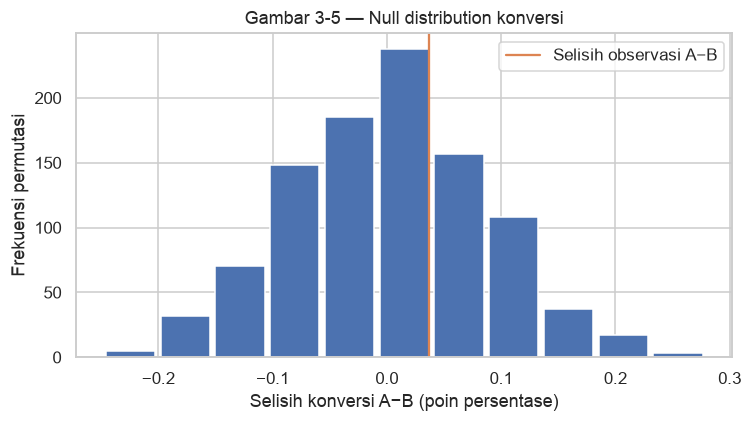

In [5]:
conversions=pd.DataFrame({'Price A':[200,23539],'Price B':[182,22406]},index=['Conversion','No conversion'])
display(conversions)
n_a,n_b=23739,22588
rate_a,rate_b=200/n_a,182/n_b
obs_conversion=100*(rate_a-rate_b)
conversion=np.r_[np.zeros(45945,dtype=int),np.ones(382,dtype=int)]
rng_conversion=np.random.default_rng(SEED)
perm_conversion=np.array([-100*perm_diff_b_minus_a(conversion,n_a,n_b,rng_conversion) for _ in range(1000)])
p_conversion=monte_carlo_p(perm_conversion,obs_conversion)
print(f'A={100*rate_a:.4f}%; B={100*rate_b:.4f}%')
print(f'Selisih A−B={obs_conversion:.6f} poin persentase; lift relatif={(rate_a/rate_b-1)*100:.3f}%')
print(f'p permutasi satu sisi = {p_conversion:.4f}')
plt.hist(perm_conversion,bins=11,rwidth=.9)
plt.axvline(obs_conversion,color='C1',label='Selisih observasi A−B')
plt.title('Gambar 3-5 — Null distribution konversi')
plt.xlabel('Selisih konversi A−B (poin persentase)'); plt.ylabel('Frekuensi permutasi')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Lift relatif sekitar 4,56% terdengar besar, tetapi selisih absolut hanya sekitar 0,0368 poin persentase. Walaupun exposure puluhan ribu, jumlah konversi yang informatif hanya ratusan. Signifikansi statistik dan manfaat bisnis harus dinilai terpisah.

<a id="c3-14"></a>
## p-Value

*Acuan: cetak 106; PDF 124. Jenis: Reproduksi buku + pembanding exact tambahan.*

P-value adalah peluang statistik setidaknya se-ekstrem observasi **dengan syarat model nol benar**. Ia bukan $P(H_0\mid data)$ dan bukan probabilitas “hasil ini hanya kebetulan”. Pada tabel 2×2 berikut, chi-square dengan continuity correction memberi p dua sisi; untuk arah A>B yang teramati, setengahnya mereproduksi pendekatan buku. Sebagai pembanding, hypergeometric memberikan ekor exact yang mempertahankan margin.

In [6]:
chi_conv,p_conv_two,df_conv,_=stats.chi2_contingency(conversions.T.to_numpy(),correction=True)
p_conv_one=p_conv_two/2 if rate_a>=rate_b else 1-p_conv_two/2
p_conv_exact=stats.hypergeom.sf(199,46327,382,23739)
display(pd.Series({'p permutasi Monte Carlo':p_conversion,
                   'p pendekatan buku (continuity corrected, satu sisi)':p_conv_one,
                   'p exact hypergeometric (A≥200)':p_conv_exact}).to_frame('hasil'))

,hasil
p permutasi Monte Carlo,0.354645
"p pendekatan buku (continuity corrected, satu sisi)",0.349780
p exact hypergeometric (A≥200),0.349938


**Interpretasi dan catatan belajar.** Nilai sekitar sepertiga menunjukkan data tidak sangat bertentangan dengan H0. Perbedaan permutasi, continuity correction, dan exact berasal dari Monte Carlo serta pendekatan distribusi; tidak perlu dipaksa identik.

<a id="c3-15"></a>
## Alpha

*Acuan: cetak 107; PDF 125. Jenis: Teori.*

Alpha $\alpha$ adalah ambang yang ditetapkan sebelum melihat hasil, misalnya 0,05. Di bawah H0 dan prosedur uji yang valid, alpha mengendalikan tingkat salah menolak H0 dalam pengulangan. Ia bukan probabilitas bahwa keputusan tertentu benar. Hasil p=0,049 dan p=0,051 tidak mewakili dua dunia yang sama sekali berbeda.

Pesan prinsip ASA yang dirangkum buku: laporkan metode dan pencarian secara transparan, jangan membuat keputusan hanya berdasarkan ambang, dan jangan menyamakan p kecil dengan ukuran efek besar. Jika banyak uji dilakukan, alpha per uji tidak sama dengan risiko gabungan.

<a id="c3-16"></a>
## Type 1 and Type 2 Errors

*Acuan: cetak 109; PDF 127. Jenis: Teori.*

**Type I**: menolak H0 padahal H0 benar. **Type II**: gagal menolak H0 padahal alternatif tertentu benar, dengan peluang $\beta$. **Power** $=1-\beta$ mengukur peluang mendeteksi efek tertentu. Gagal menolak bukan “menerima H0 sebagai fakta”; eksperimen bisa kurang sensitif.

Menurunkan alpha pada ukuran sampel tetap biasanya menurunkan power. Ukuran efek, noise, jumlah subjek, dan arah uji memengaruhi tradeoff. Pada sesi A/B, hasil nonsignifikan tidak membuktikan tidak ada perbaikan; interval ketidakpastian dan kebutuhan eksperimen berikutnya masih relevan.

<a id="c3-17"></a>
## Data Science and p-Values

*Acuan: cetak 109; PDF 127. Jenis: Teori.*

P-value dapat menjadi satu informasi untuk menyaring temuan, tetapi prediksi di data baru, besarnya efek, dan biaya implementasi tetap penting. Sampel sangat besar bisa mendeteksi perubahan yang terlalu kecil untuk bernilai praktis. Sebaliknya, efek yang secara bisnis berarti bisa tidak signifikan karena sedikit konversi. Jika tujuan mencari treatment terbaik secara berkelanjutan, pertimbangkan masalah optimasi seperti bandit, bukan hanya satu uji signifikansi.

<a id="c3-18"></a>
## t-Tests

*Acuan: cetak 110; PDF 128. Jenis: Reproduksi dengan alternative eksplisit.*

Welch t-test membandingkan mean dua kelompok tanpa mengasumsikan varians sama:
$$t=\frac{\bar x_A-\bar x_B}{\sqrt{s_A^2/n_A+s_B^2/n_B}}.$$
Derajat bebas memakai pendekatan Welch–Satterthwaite. Asumsi utama: kelompok independen, data numerik, dan sampling distribution cukup sesuai pendekatan t; pada sampel kecil, pencilan dan kemencengan berat dapat mengganggu. Untuk repeated measures gunakan uji berpasangan, bukan uji independen ini.

In [7]:
welch=stats.ttest_ind(a,b,equal_var=False,alternative='less')
t_sm,p_sm,df_sm=sm.stats.ttest_ind(a,b,usevar='unequal',alternative='smaller')
display(pd.DataFrame({'statistik t':[welch.statistic,t_sm],
                      'p satu sisi A<B':[welch.pvalue,p_sm],
                      'df':[welch.df,df_sm]},index=['SciPy','statsmodels']))
assert np.isclose(welch.pvalue,.1408,atol=.0001)

,statistik t,p satu sisi A<B,df
SciPy,-1.098316,0.140762,27.69337
statsmodels,-1.098316,0.140762,27.69337


**Interpretasi dan catatan belajar.** Tanda t negatif konsisten dengan mean A yang lebih kecil. P≈0,1408 searah dengan kesimpulan permutasi: selisih belum cukup kuat pada alpha 0,05. Berbeda p dari permutasi bukan error karena acuan dan asumsi tidak persis sama.

<a id="c3-19"></a>
## Multiple Testing

*Acuan: cetak 112; PDF 130. Jenis: Padanan Python contoh numerik buku.*

Pada $m$ uji independen dengan semua H0 benar, peluang setidaknya satu false positive adalah $1-(1-\alpha)^m$. Untuk 20 uji dan alpha 0,05 nilainya sekitar 64%. **Family-wise error rate (FWER)** berbeda dari **false discovery rate (FDR)**, yaitu nilai harapan proporsi temuan salah di antara temuan yang ditolak (nol bila tidak ada penolakan).

Bonferroni memakai ambang $\alpha/m$; Holm memperbaiki efisiensi sambil mengontrol FWER. Benjamini–Hochberg mengontrol FDR di bawah asumsi dependensi yang sesuai. Tukey HSD dikhususkan untuk perbandingan semua pasangan mean dengan asumsi ANOVA. Penyesuaian tidak menyelamatkan seluruh pencarian yang tidak dilaporkan. Holdout dan cross-validation mengurangi overfitting pada prediksi jika tidak ikut dipakai berulang kali memilih hasil.

Contoh komputasi hanya menghitung risiko keluarga seperti buku; tidak dibuat p-value sintetis untuk seolah-olah menjadi eksperimen nyata.

In [8]:
m,alpha=20,.05
print(f'P(≥1 salah positif; 20 uji independen) = {1-(1-alpha)**m:.4f}')
print(f'Ambang Bonferroni per uji = {alpha/m:.4f}')

P(≥1 salah positif; 20 uji independen) = 0.6415
Ambang Bonferroni per uji = 0.0025


<a id="c3-20"></a>
## Degrees of Freedom

*Acuan: cetak 116; PDF 134. Jenis: Teori.*

Derajat bebas menghitung banyak informasi bebas setelah constraint/parameter dipasang. Jika mean n nilai diketahui, n−1 nilai bebas menentukan nilai terakhir. Dalam regresi dengan p prediktor dan intercept, residual df adalah n−p−1. Dalam tabel r×c dengan margin tetap, df adalah (r−1)(c−1).

Untuk kategori dengan k level dan intercept, k−1 dummy menghindari redundansi. Memasukkan semua k dummy bersama intercept menyebabkan ketergantungan linear sempurna. Algoritme mungkin masih mengeluarkan angka lewat pseudoinverse, tetapi koefisien tidak unik.

<a id="c3-21"></a>
## ANOVA

*Acuan: cetak 118; PDF 136. Jenis: Reproduksi Python buku.*

ANOVA menguji H0 bahwa seluruh mean kelompok sama. Ia merupakan **omnibus test**: penolakan hanya menyatakan ada perbedaan, bukan menentukan pasangan mana. Contoh empat halaman memiliki lima sesi independen per halaman.

Permutasi buku memakai varians keempat mean sebagai statistik dan 3.000 pengulangan. Ukuran kelompok sama membuat statistik ini mudah dipakai. Tabel mean/grand mean yang tercetak dalam prosa buku tidak semuanya konsisten dengan 20 angka mentah; notebook menghitung mean langsung dari CSV yang memuat angka pengamatan tersebut.

,mean durasi (detik)
Page,
Page 1,172.8
Page 2,182.6
Page 3,175.6
Page 4,164.6


Grand mean dari data=173.9000; variance mean=55.4267; p permutasi=0.0803


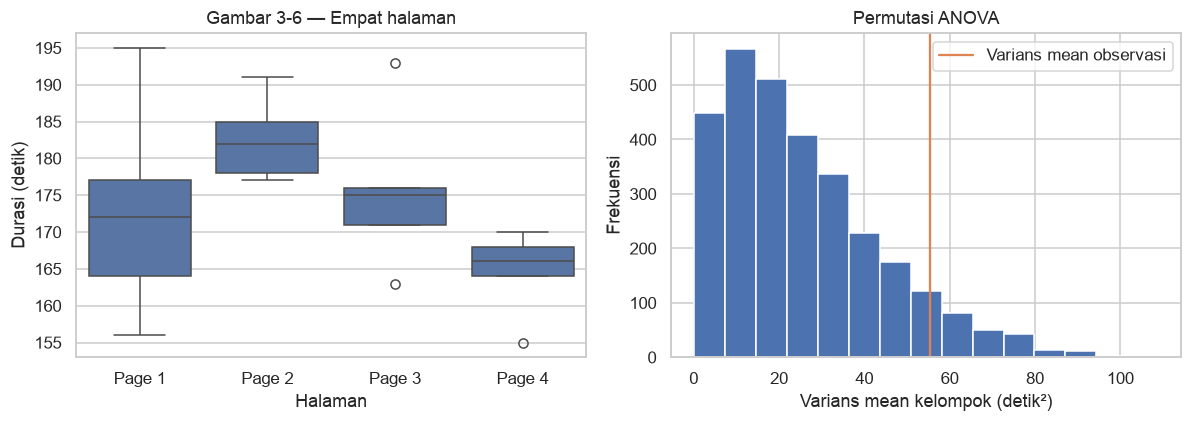

In [9]:
page_means=four.groupby('Page').Time.mean()
obs_var=page_means.var(ddof=1)
rng_anova=np.random.default_rng(SEED)
labels=four.Page.to_numpy()
values=four.Time.to_numpy()
groups=[np.flatnonzero(labels==p) for p in sorted(four.Page.unique())]
perm_var=[]
for _ in range(3000):
    shuffled=rng_anova.permutation(values)
    perm_var.append(np.var([shuffled[idx].mean() for idx in groups],ddof=1))
perm_var=np.asarray(perm_var)
p_anova_perm=monte_carlo_p(perm_var,obs_var)
display(page_means.to_frame('mean durasi (detik)'))
print(f'Grand mean dari data={four.Time.mean():.4f}; variance mean={obs_var:.4f}; p permutasi={p_anova_perm:.4f}')
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=four,x='Page',y='Time',ax=axes[0])
axes[0].set(title='Gambar 3-6 — Empat halaman',xlabel='Halaman',ylabel='Durasi (detik)')
axes[1].hist(perm_var,bins=15)
axes[1].axvline(obs_var,color='C1',label='Varians mean observasi')
axes[1].set(title='Permutasi ANOVA',xlabel='Varians mean kelompok (detik²)',ylabel='Frekuensi')
axes[1].legend(); plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Mean antarkelompok berbeda secara deskriptif, tetapi hasil uji harus menilai variasi dalam kelompok juga. Nonsignifikansi pada 5% tidak menjamin semua halaman sama. Angka dari CSV dipakai konsisten untuk mean, ANOVA, dan interpretasi.

<a id="c3-22"></a>
## F-Statistic

*Acuan: cetak 121; PDF 139. Jenis: Reproduksi dengan koreksi F, p, dan df.*

ANOVA memisahkan $SS_{between}=\sum_g n_g(\bar y_g-\bar y)^2$ dan $SS_{within}=\sum_g\sum_i(y_{ig}-\bar y_g)^2$. Untuk G kelompok dan N observasi:
$$F=\frac{SS_{between}/(G-1)}{SS_{within}/(N-G)}.$$
Pada contoh N=20, G=4, df pembilang 3 dan penyebut 16. Angka 20 yang disebut sebagai residual df pada prosa cetak tidak sesuai tabel ANOVA dan dikoreksi di sini. Model klasik mengasumsikan error independen, kira-kira normal dalam kelompok, dan varians sama.

**Koreksi repository:** `f_oneway` sudah menghasilkan F dan p ANOVA. Keduanya tidak boleh dibagi dua seperti baris cetak di skrip pendamping. Distribusi F menggunakan ekor kanan.

In [10]:
anova_model=smf.ols('Time ~ C(Page)',data=four).fit()
anova_table=sm.stats.anova_lm(anova_model)
f_result=stats.f_oneway(*[four.loc[four.Page==p,'Time'] for p in sorted(four.Page.unique())])
display(anova_table)
print(f'SciPy F={f_result.statistic:.6f}; p={f_result.pvalue:.6f}')
assert np.isclose(f_result.statistic,anova_table['F'].iloc[0])
assert np.isclose(f_result.pvalue,.0776,atol=.0001)
# Contoh dekomposisi observasi pertama: grand mean + efek kelompok + residual.
first=four.iloc[0]
grand=four.Time.mean(); group_mean=page_means.loc[first.Page]
display(pd.Series({'grand mean':grand,'efek kelompok':group_mean-grand,
                  'residual':first.Time-group_mean,'jumlah':grand+(group_mean-grand)+(first.Time-group_mean)}))

,df,sum_sq,mean_sq,F,PR(>F)
C(Page),3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


SciPy F=2.739825; p=0.077586


grand mean       173.9
efek kelompok     -1.1
residual          -8.8
jumlah           164.0
dtype: float64

**Interpretasi dan catatan belajar.** F sekitar 2,74 dan p sekitar 0,0776. Pada alpha 0,05 belum menolak kesamaan mean. Pendekatan F dan randomisasi tidak menghasilkan p identik, tetapi kesimpulan pada ambang ini sama.

<a id="c3-23"></a>
## Two-Way ANOVA

*Acuan: cetak 123; PDF 141. Jenis: Teori.*

Two-way ANOVA menambahkan faktor kedua, misalnya halaman dan weekday/weekend. Model dapat memuat dua main effects dan interaksi: $Y=\mu+\alpha_{page}+\beta_{day}+\gamma_{page,day}+\epsilon$. Interaksi berarti perbedaan antarhalaman tergantung jenis hari.

Padanan formula Python adalah `Time ~ C(Page) * C(DayType)`. CSV buku `four_sessions` tidak memiliki `DayType`; karena itu formula dijelaskan tanpa membuat kolom hari fiktif. Bagian ini konseptual pada PDF dan tidak ada hasil eksperimen two-way yang diklaim.

<a id="c3-24"></a>
## Chi-Square Test

*Acuan: cetak 124; PDF 142. Jenis: Reproduksi tabel 3-4 sampai 3-6.*

Uji chi-square pada contingency table menilai independensi dua variabel kategorikal. Expected count di bawah H0 adalah $E_{ij}=R_iC_j/N$, dengan $R_i$ total baris, $C_j$ total kolom. Pearson residual adalah $(O_{ij}-E_{ij})/\sqrt{E_{ij}}$ dan statistik $\chi^2$ adalah jumlah kuadrat residual itu.

Contoh tiga headline masing-masing memiliki 1.000 exposure. Jangan memasukkan persentase ke `chi2_contingency` sebagai pengganti hitungan; ukuran sampel merupakan informasi yang diperlukan.

In [11]:
clicks=click_rate.pivot(index='Click',columns='Headline',values='Rate').loc[['Click','No-click']]
observed_clicks=clicks.to_numpy()
expected_clicks=np.outer(observed_clicks.sum(axis=1),observed_clicks.sum(axis=0))/observed_clicks.sum()
pearson=(observed_clicks-expected_clicks)/np.sqrt(expected_clicks)
obs_chi=float(np.square(pearson).sum())
display(clicks)
display(pd.DataFrame(expected_clicks,index=clicks.index,columns=clicks.columns))
display(pd.DataFrame(pearson,index=clicks.index,columns=clicks.columns))
print('χ² observasi:',obs_chi)

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


Headline,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


Headline,Headline A,Headline B,Headline C
Click,,,
Click,0.792118,-0.990148,0.198030
No-click,-0.084809,0.106012,-0.021202


χ² observasi: 1.6659394708658917


**Interpretasi dan catatan belajar.** Expected click tiap headline sekitar 11,33. Headline A memiliki klik lebih banyak dari expected dan B lebih sedikit, tetapi besarnya deviasi harus dibandingkan dengan variasi acak.

<a id="c3-25"></a>
## Chi-Square Test: A Resampling Approach

*Acuan: cetak 124; PDF 142. Jenis: Reproduksi dengan perbaikan algoritme permutasi.*

Null model mempertahankan total 34 klik dan membaginya acak ke tiga kelompok **saling lepas** berukuran 1.000. Ini mengikuti algoritme naratif dan implementasi utama repository terbaru.

Kode Python PDF melakukan tiga `random.sample(box,1000)` terpisah sehingga record dapat tumpang tindih antarkelompok dan total klik tidak tetap; itu bukan permutasi dengan margin tetap. Implementasi berikut memperbaikinya dengan satu shuffle dan tiga irisan. Hasil disimpan sebagai NumPy array agar perbandingan elemen tidak mengandalkan perilaku list.

In [12]:
rng_chi=np.random.default_rng(SEED)
box=np.r_[np.ones(34,dtype=int),np.zeros(2966,dtype=int)]
perm_chi=[]
for _ in range(2000):
    counts=rng_chi.permutation(box).reshape(3,1000).sum(axis=1)
    table=np.vstack([counts,1000-counts])
    perm_chi.append(((table-expected_clicks)**2/expected_clicks).sum())
perm_chi=np.asarray(perm_chi)
p_chi_perm=monte_carlo_p(perm_chi,obs_chi)
print(f'χ²={obs_chi:.4f}; p permutasi dengan ties={p_chi_perm:.4f}')
print(f'p strict > (pola kode buku)={np.mean(perm_chi>obs_chi):.4f}')

χ²=1.6659; p permutasi dengan ties=0.4843
p strict > (pola kode buku)=0.4600


**Interpretasi dan catatan belajar.** Expected count dan total margin tetap dalam setiap permutasi. Statistik ini diskret sehingga menyertakan ties dapat mengubah p cukup nyata; perbedaan dengan hasil cetak tidak hanya akibat seed.

<a id="c3-26"></a>
## Chi-Square Test: Statistical Theory

*Acuan: cetak 127; PDF 145. Jenis: Reproduksi Python buku.*

Di bawah independensi dan sampel yang cukup, statistik Pearson mendekati $\chi^2_{(r-1)(c-1)}$. Untuk tabel 2×3, df=2. Expected count kecil dan observasi yang tidak independen dapat merusak pendekatan tersebut. P-value dihitung pada ekor kanan: deviasi lebih besar memberi statistik lebih besar.

χ²=1.6659; df=2; p=0.4348


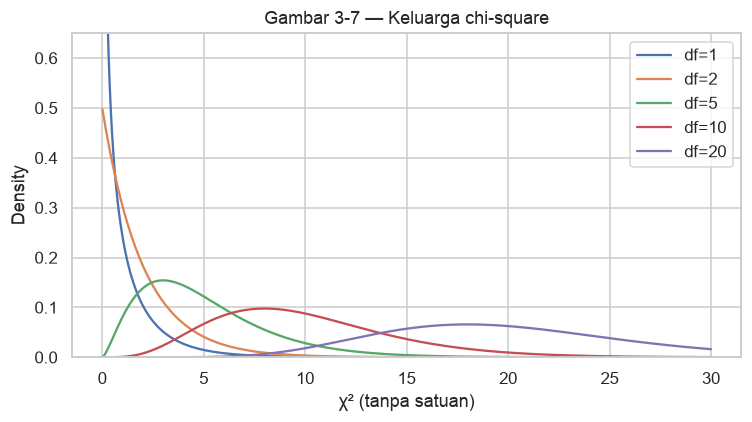

In [13]:
chi,p_chi,df_chi,expected=stats.chi2_contingency(observed_clicks,correction=False)
print(f'χ²={chi:.4f}; df={df_chi}; p={p_chi:.4f}')
assert np.isclose(chi,1.665939,atol=1e-5)
x=np.linspace(.01,30,500)
for d in [1,2,5,10,20]: plt.plot(x,stats.chi2.pdf(x,d),label=f'df={d}')
plt.ylim(0,.65); plt.title('Gambar 3-7 — Keluarga chi-square')
plt.xlabel('χ² (tanpa satuan)'); plt.ylabel('Density'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** P≈0,4348 tidak memberi bukti kuat bahwa headline memengaruhi klik. Kurva df kecil sangat miring; df yang lebih besar menggeser pusat ke kanan. P pendekatan dan p exact/permutasi berbeda karena distribusi diskret hanya didekati kurva kontinu.

<a id="c3-27"></a>
## Fisher’s Exact Test

*Acuan: cetak 128; PDF 146. Jenis: Padanan Python contoh R-only; enumerasi exact.*

Fisher exact mempertahankan margin tabel dan menjumlahkan peluang tabel yang setidaknya se-ekstrem tabel teramati. Untuk tabel 2×3 ini, semua alokasi 34 klik ke tiga kolom dapat dienumerasi dengan murah. Peluang konfigurasi $(a,b,c)$ adalah $\binom{1000}{a}\binom{1000}{b}\binom{1000}{c}/\binom{3000}{34}$, dengan $a+b+c=34$.

**Padanan Python contoh R buku:** gunakan probability ordering (peluang tabel ≤ peluang observasi), bukan otomatis threshold chi-square. Fungsi log-gamma mencegah overflow. Enumerasi ini khusus ukuran/margin contoh, tidak diklaim efisien untuk semua tabel besar; tidak perlu compiler Fortran atau paket tambahan.

In [14]:
def logchoose(n,k):
    return gammaln(n+1)-gammaln(k+1)-gammaln(n-k+1)

observed_logp=sum(logchoose(1000,int(k)) for k in observed_clicks[0])-logchoose(3000,34)
logprobs=[]
for k1 in range(35):
    for k2 in range(35-k1):
        k3=34-k1-k2
        logprobs.append(logchoose(1000,k1)+logchoose(1000,k2)+logchoose(1000,k3)-logchoose(3000,34))
logprobs=np.asarray(logprobs)
assert np.isclose(np.exp(logsumexp(logprobs)),1,atol=1e-9)
p_fisher=float(np.exp(logsumexp(logprobs[logprobs<=observed_logp+1e-10])))
print('Jumlah tabel yang dienumerasi:',len(logprobs))
print(f'Fisher–Freeman–Halton exact 2×3: p={p_fisher:.6f}; buku R≈0,4824')
assert np.isclose(p_fisher,.4824,atol=.0001)

Jumlah tabel yang dienumerasi: 630
Fisher–Freeman–Halton exact 2×3: p=0.482414; buku R≈0,4824


**Interpretasi dan catatan belajar.** Hasil mendekati 0,4824 seperti R di buku. Semua kemungkinan margin dievaluasi, sehingga tidak ada galat Monte Carlo. P exact berbasis peluang tabel dan p permutasi berbasis chi-square memakai definisi ekstrem yang perlu dibedakan meskipun hasil bisa dekat.

<a id="c3-28"></a>
## Relevance for Data Science

*Acuan: cetak 130; PDF 148. Jenis: Reproduksi grafik + uji goodness-of-fit tambahan.*

Chi-square dapat dipakai sebagai penyaring hubungan fitur kategorikal, evaluasi hasil web, atau goodness of fit. Jika dilakukan untuk ribuan fitur, masalah multiple testing kembali muncul; signifikansi juga tidak menjamin manfaat prediksi di data baru.

**Contoh frekuensi digit buku (cetak 129–130):** hipotesis null menganggap sepuluh digit interior sama mungkin. Data menyimpang dari uniform, tetapi uji ini tidak membuktikan sebab penyimpangan atau tindakan curang. Buku menyatakan peneliti terkait akhirnya dibebaskan dari tuduhan. Analisis di bawah hanya membandingkan distribusi digit dengan model uniform.

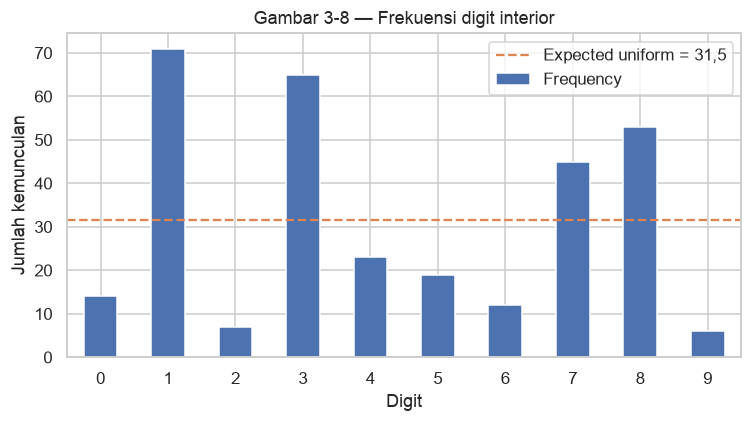

Total digit: 315
Tambahan goodness-of-fit: χ²=174.365; p=7.6e-33


In [15]:
uniform_test=stats.chisquare(digits.Frequency)
ax=digits.plot.bar(x='Digit',y='Frequency',legend=False,rot=0)
ax.axhline(digits.Frequency.sum()/10,color='C1',ls='--',label='Expected uniform = 31,5')
ax.set(title='Gambar 3-8 — Frekuensi digit interior',xlabel='Digit',ylabel='Jumlah kemunculan')
ax.legend(); plt.tight_layout(); plt.show()
print('Total digit:',digits.Frequency.sum())
print(f'Tambahan goodness-of-fit: χ²={uniform_test.statistic:.3f}; p={uniform_test.pvalue:.3g}')

**Interpretasi dan catatan belajar.** Tinggi bar sangat tidak merata dibanding expected 31,5. P kecil menyatakan ketidakcocokan dengan uniform-independen; validitas asumsi pengukuran dan proses pembentukan digit harus dinilai terpisah.

<a id="c3-29"></a>
## Multi-Arm Bandit Algorithm

*Acuan: cetak 131; PDF 149. Jenis: Teori + tambahan kebijakan dari contoh naratif.*

Bandit menyeimbangkan **exploration** (mencoba alternatif untuk belajar) dan **exploitation** (memakai yang saat ini terbaik). Pada contoh buku, A memiliki 10/50 kemenangan, B 2/50, dan C 4/50. Memilih A selamanya mengabaikan ketidakpastian; membagi sama selamanya bisa membuang peluang reward.

Pada epsilon-greedy dengan K arm, setiap arm mendapat probabilitas eksplorasi $\epsilon/K$, sedangkan arm terbaik mendapat tambahan $1-\epsilon$. $\epsilon=1$ berarti seluruhnya acak; $\epsilon=0$ murni greedy. Thompson sampling memelihara distribusi posterior reward, menarik satu nilai untuk tiap arm, dan memilih yang terbesar. Untuk reward Bernoulli, prior Beta diperbarui dengan jumlah sukses dan gagal.

Berikut **tambahan implementasi kebijakan satu langkah**, memakai hitungan naratif buku. Tidak disimulasikan klik pengguna baru. Alokasi adaptif mengubah desain; p-value fixed-design tidak boleh diterapkan tanpa memperhitungkan proses adaptasinya.

In [16]:
wins=np.array([10,2,4]); pulls=np.array([50,50,50]); epsilon=.1
rates=wins/pulls
allocation=np.full(3,epsilon/3)
allocation[np.argmax(rates)]+=1-epsilon
display(pd.DataFrame({'arm':['A','B','C'],'menang':wins,'percobaan':pulls,
                      'rate observasi':rates,'probabilitas epsilon-greedy':allocation}))
rng_bandit=np.random.default_rng(SEED)
posterior_draw=rng_bandit.beta(1+wins,1+pulls-wins)
print('Satu draw Thompson (prior Beta(1,1)):',posterior_draw)
print('Arm dipilih pada draw ini:','ABC'[int(np.argmax(posterior_draw))])

,arm,menang,percobaan,rate observasi,probabilitas epsilon-greedy
0,A,10,50,0.20,0.933333
1,B,2,50,0.04,0.033333
2,C,4,50,0.08,0.033333


Satu draw Thompson (prior Beta(1,1)): [0.21658668 0.08968754 0.10502902]
Arm dipilih pada draw ini: A


**Interpretasi dan catatan belajar.** Probabilitas alokasi adalah aturan keputusan, bukan probabilitas pasti bahwa arm terbaik benar-benar unggul. Satu draw Thompson dapat memilih alternatif karena masih ada ketidakpastian. Ini menghubungkan statistik dengan pengambilan keputusan adaptif.

<a id="c3-30"></a>
## Power and Sample Size

*Acuan: cetak 135; PDF 153. Jenis: Teori.*

Power $=P(\text{tolak }H_0\mid\text{efek tertentu benar})$ tergantung ukuran efek, ukuran sampel, noise, alpha, dan arah uji. Power bukan peluang H1 benar setelah data diamati. Contoh buku ingin membedakan laju dasar 1,1% dari laju yang 10% atau 50% lebih tinggi.

Perencanaan dapat memakai simulasi: bangkitkan dua kelompok dari skenario alternatif, lakukan uji, ulangi, lalu hitung proporsi penolakan. Skenario harus mencerminkan efek minimum yang berguna. Power tidak cukup ditentukan oleh satu hasil eksperimen atau satu p-value.

<a id="c3-31"></a>
## Sample Size

*Acuan: cetak 136; PDF 154. Jenis: Reproduksi Python + pembanding metode.*

Reproduksi memakai `proportion_effectsize` (Cohen h): $h=2\arcsin\sqrt{p_1}-2\arcsin\sqrt{p_0}$. Python buku memasukkan h ke `TTestIndPower`; kita tampilkan hasil itu, lalu bandingkan `NormalIndPower`, pendekatan dua proporsi pada skala arcsine yang lebih dekat dengan fungsi R buku.

Dengan alpha=0,05, power=0,8, alternatif “lebih besar”, ratio=1, hasil n berarti **exposure per kelompok**, bukan jumlah klik atau total dua kelompok. Target 1,21% merupakan peningkatan relatif 10% dari 1,1%, yakni 0,11 poin persentase.

In [17]:
power_rows=[]
for target in [.0121,.0165]:
    h=sm.stats.proportion_effectsize(target,.011)
    n_t=sm.stats.TTestIndPower().solve_power(effect_size=h,alpha=.05,power=.8,ratio=1,alternative='larger')
    n_normal=sm.stats.NormalIndPower().solve_power(effect_size=h,alpha=.05,power=.8,ratio=1,alternative='larger')
    power_rows.append({'p dasar':.011,'p target':target,'Cohen h':h,
                       'n TTestIndPower (buku)':n_t,'n NormalIndPower':n_normal,
                       'n per kelompok dibulatkan (buku)':math.ceil(n_t),
                       'total exposure (buku)':2*math.ceil(n_t)})
display(pd.DataFrame(power_rows))

,p dasar,p target,Cohen h,n TTestIndPower (buku),n NormalIndPower,n per kelompok dibulatkan (buku),total exposure (buku)
0,0.011,0.0121,0.010298,116602.391267,116601.714875,116603,233206
1,0.011,0.0165,0.047468,5488.407720,5487.731209,5489,10978


**Interpretasi dan catatan belajar.** Efek relatif 10% membutuhkan sekitar 116.603 exposure per kelompok, sedangkan efek 50% sekitar 5.489. Mendeteksi perbaikan kecil pada event langka mahal. Perbedaan kecil Python–R berasal dari pendekatan t versus normal; angka final mengikuti output aktual dan pembulatan ke atas.

<a id="c3-32"></a>
## Summary

*Acuan: cetak 139; PDF 157. Jenis: Teori.*

Desain menentukan apakah kelompok layak dibandingkan; statistik tidak memperbaiki randomisasi yang gagal. Pada data sesi, konversi, ANOVA empat halaman, dan headline, perbedaan observasi belum cukup untuk menolak H0 pada alpha 5%. Contoh digit menunjukkan ketidakcocokan distribusi tetapi tidak menetapkan penyebab.

**Latihan:** tulis H0/H1 dan arah statistik untuk dua contoh A/B; jelaskan mengapa 0,0368 poin persentase berbeda dari lift 4,56%; hitung residual df ANOVA; jelaskan mengapa exact tidak sama dengan “pasti benar”; bandingkan tujuan bandit dengan power analysis.

**Bacaan lanjutan buku:** Edgington–Onghena tentang randomization tests; Cobb tentang desain eksperimen; White tentang bandit; Ryan tentang power dan ukuran sampel. Diagram alur inferensi dijelaskan dalam teks; ilustrasi pemasaran tidak disalin.

## Referensi dan atribusi

- Peter Bruce, Andrew Bruce, Peter Gedeck. *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*, edisi 2, O’Reilly, 2020. ISBN 978-1-492-07294-2, Bab 3.
- [Kode dan dataset resmi pada commit tetap](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa); sumber khusus: `python/code/Chapter 3*.py` dan notebook pendamping. Copyright kode upstream © 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck. Modifikasi untuk tugas: penjelasan Indonesia, seed, API, pemeriksaan hasil, dan tambahan belajar yang ditandai. Lisensi GPL-3.0: lihat [LICENSE](LICENSE).
- Bacaan lanjutan yang disebut buku dirangkum di bagian akhir bab; rujuk buku untuk bibliografi lengkap.

**Refleksi mahasiswa:** tuliskan bagian yang paling sulit, perubahan kode yang Anda coba, dan satu contoh penerapan pada Teknik Komputer. Jangan mengklaim telah melakukan eksperimen nyata dari data contoh ini.